# Mini Lab (20 min) — 2D Discrete Wavelet Transform (DWT): Denoising & Compression

**Audience:** M1 Engineering  
**Goal:** understand multiresolution decomposition (approximation + horizontal/vertical/diagonal details) and use it to **denoise** and **compress** an image.


In [ ]:
# Pré-requis : pywavelets, scikit-image, matplotlib, pillow
import numpy as np
import pywt, inspect
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.util import random_noise
from PIL import Image
import os

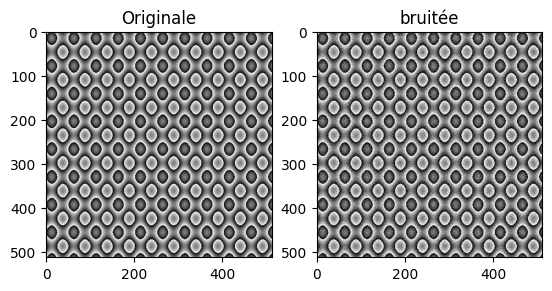

In [ ]:

# 1) Image de test + ajout de bruit
if os.path.exists('camera.png'):
    img = img_as_float(np.array(Image.open('camera.png').convert('L')))
else:
    img = img_as_float(data.camera())
bruitee = random_noise(img, mode='gaussian', var=0.01)

plt.subplot(1,2,1);plt.imshow(img,cmap='grey');plt.title('Originale')
plt.subplot(1,2,2);plt.imshow(bruitee,cmap='grey');plt.title('bruitée')
plt.show()

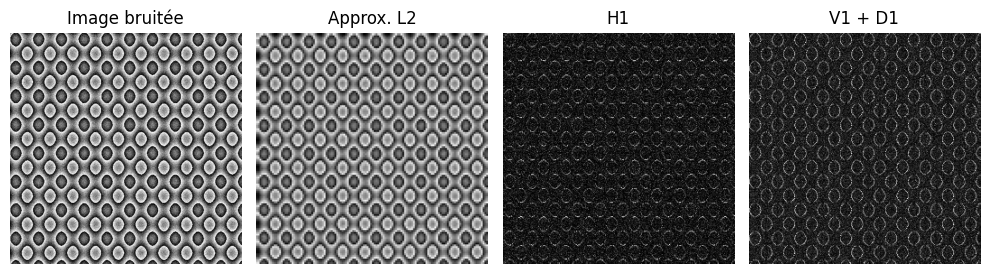

In [39]:


# 2) Décomposition en ondelettes 2D (DWT)
ondelette = 'db2'
niveau = 2
coeffs = pywt.wavedec2(bruitee, wavelet=ondelette, level=niveau)
A, details = coeffs[0], coeffs[1:]   # A : approximation, details : [(H,V,D)_L, ..., (H,V,D)_1]

# 3) Visualisation des sous-bandes de niveau 1
(H1, V1, D1) = details[-1]
plt.figure(figsize=(10,3))
plt.subplot(1,4,1); plt.imshow(bruitee, cmap='gray'); plt.title('Image bruitée'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(A, cmap='gray');       plt.title('Approx. L2'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(np.abs(H1), cmap='gray'); plt.title('H1'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(np.abs(V1)+np.abs(D1), cmap='gray'); plt.title('V1 + D1'); plt.axis('off')
plt.tight_layout(); plt.show()


PSNR bruitée :   20.46 dB
PSNR débruitée : 17.31 dB
PSNR compressée (7%): 18.10 dB


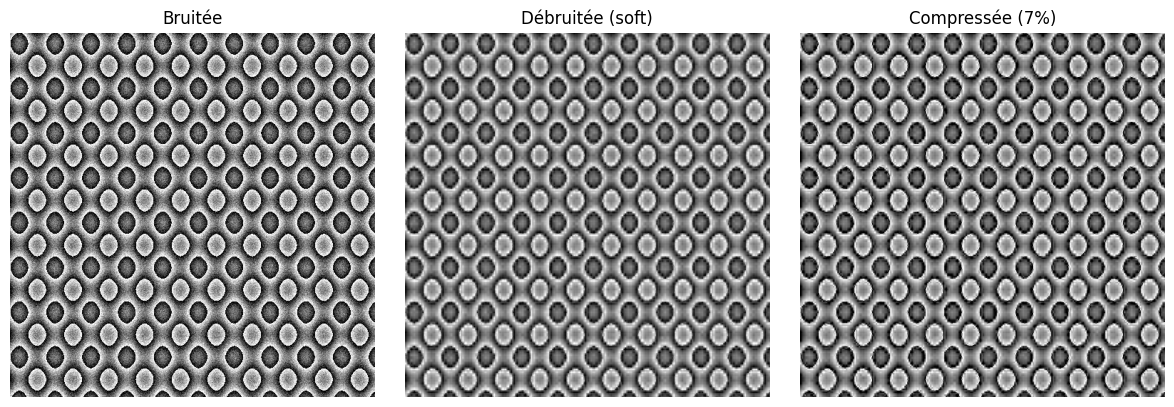

In [67]:

# 4) Dénoyautage par seuillage doux (soft-thresholding)
mode = 'soft'
sigma = np.median(np.abs(D1)) / 0.6745
N = bruitee.size
T = sigma * np.sqrt(2*np.log(N))

def seuillage_doux(coeffs, T):
    cA = coeffs[0]
    nouveaux_details = []
    for (cH, cV, cD) in coeffs[1:]:
        nouveaux_details.append((
            pywt.threshold(cH, T, mode=mode),
            pywt.threshold(cV, T, mode=mode),
            pywt.threshold(cD, T, mode=mode),
        ))
    return [cA] + nouveaux_details

coeffs_denoises = seuillage_doux(coeffs, T)
denoisee = pywt.waverec2(coeffs_denoises, wavelet=ondelette)
denoisee = np.clip(denoisee, 0, 1)

# 5) Compression : conservation des k% plus grands coefficients
k_pourcent = 7  # on garde les 5% plus grands coefficients

def coeffs_vers_array_compat(coeffs):
    if 'output_format' in inspect.signature(pywt.coeffs_to_array).parameters:
        return pywt.coeffs_to_array(coeffs, padding=None, output_format='wavedec2')
    return pywt.coeffs_to_array(coeffs)

def array_vers_coeffs_compat(arr, slices):
    try:
        return pywt.array_to_coeffs(arr, slices, output_format='wavedec2')
    except TypeError:
        return pywt.array_to_coeffs(arr, slices)

arr, slices = coeffs_vers_array_compat(coeffs)
plat = arr.ravel()
k = max(1, int(np.ceil(len(plat) * (k_pourcent / 100.0))))
idx = np.argpartition(np.abs(plat), -k)[-k:]
masque = np.zeros_like(plat, dtype=bool); masque[idx] = True
arr_comp = np.where(masque.reshape(arr.shape), arr, 0.0)

coeffs_comp = array_vers_coeffs_compat(arr_comp, slices)
reconstruit_comp = pywt.waverec2(coeffs_comp, wavelet=ondelette)
reconstruit_comp = np.clip(reconstruit_comp, 0, 1)

# 6) PSNR + affichage des résultats
def psnr(x, y):
    mse = np.mean((x - y)**2)
    return 99. if mse == 0 else 10*np.log10(1.0/mse)

print(f"PSNR bruitée :   {psnr(img, bruitee):.2f} dB")
print(f"PSNR débruitée : {psnr(img, denoisee):.2f} dB")
print(f"PSNR compressée ({k_pourcent}%): {psnr(img, reconstruit_comp):.2f} dB")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(bruitee, cmap='gray');       plt.title('Bruitée'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(denoisee, cmap='gray');      plt.title(f'Débruitée ({mode})'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(reconstruit_comp, cmap='gray'); plt.title(f'Compressée ({k_pourcent}%)'); plt.axis('off')
plt.tight_layout(); plt.show()


### Quick variants (if time allows)
- Change `wavelet`: `'haar'`, `'db4'`, `'sym4'`, `'coif1'`…  
- Try `level = 1` vs `3`.  
- Compare **soft** vs **hard** thresholding (artifacts vs smoothing).

## Questions (5 min)
1. What do \(H_1, V_1, D_1\) capture (links to horizontal/vertical/diagonal edges)?  
2. How does denoising change when you increase/decrease the **threshold T**?  
3. Up to which **k%** of kept coefficients is quality acceptable?  
4. Why do some wavelets (e.g., `db4`) produce fewer “staircase” artifacts than `haar`?


Réponses

1. \(H_1, V_1, D_1\) sont les amplitudes des ondelettes du niveau correspondant (ici details[-1] soit de la plus haute fréquence : les détails fins), pour chaque direction correspondantes.\
En bref ce sont les contours en fonction de leurs direction (H,V,D) et de leurs 'sharpness' (niveau)

2. T est le seuil en-dessous de quoi les valeurs des coefficients sont mis à zéros.\
Quand on réduit le seuil, on conserve plus de détails (dont du bruit), et inversement.

3. A k= 15 (compression à 85%) le PSNR est maximal (23.60 dB). En général on considère correcte à 30dB.\
A k = 7 (compression à 93%) le PSNR est supérieur au PSNR de l'image débruitée

4. 'haar' est une fonction assez brute (en escaliers), tandis que 'db4' est plus lisse, celà semble induire des artefacts également plus doux (avec 'db4')

